# Setup & Imports

In [28]:
%cd /content/drive/MyDrive/Colab\ Notebooks/transformer

/content/drive/MyDrive/Colab Notebooks/transformer


In [29]:
# Sacrebleu for BLEU score
import os
try:
    import sacrebleu
    from sacrebleu.metrics import BLEU, CHRF, TER
    print("sacrebleu available")
except ImportError:
    os.system("pip install sacrebleu -q")
    import sacrebleu
    from sacrebleu.metrics import BLEU, CHRF, TER

sacrebleu available


In [30]:
import sys, json, math, time, warnings
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns
from collections import defaultdict, Counter
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120
sns.set_style("whitegrid")

# Project imports
from config import cfg, validate_config
from transformer import build_transformer
from loss import LabelSmoothingLoss
from dataset import TranslationDataset, collate_fn
from inference import greedy_decode, beam_search_decode
from masks import make_src_mask
from torch.utils.data import DataLoader
from tokenizers import Tokenizer


validate_config(cfg)
device = cfg.device
print(f"\nDevice: {device}")
print(f"Config: d_model={cfg.d_model}, n_heads={cfg.n_heads}, n_layers={cfg.n_layers}")
print(f"        vocab_size={cfg.vocab_size}, max_seq_len={cfg.max_seq_len}")

[Config] Validated. d_model=512, n_heads=8, d_k=64, n_layers=6, d_ff=2048
[Config] Device: cuda

Device: cuda
Config: d_model=512, n_heads=8, n_layers=6
        vocab_size=37000, max_seq_len=128


# Load Tokenizer & Test Data

In [31]:
CHECKPOINT_DIR = "./checkpoints"
TOKENIZER_PATH = "bpe_tokenizer.json"
BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "best_model.pt")

# Load tokenizer
tokenizer = Tokenizer.from_file(TOKENIZER_PATH)
PAD_ID = tokenizer.token_to_id("<pad>")
SOS_ID = tokenizer.token_to_id("<sos>")
EOS_ID = tokenizer.token_to_id("<eos>")
print(f"Tokenizer loaded. Vocab size: {tokenizer.get_vocab_size():,}")
print(f"  PAD={PAD_ID}, SOS={SOS_ID}, EOS={EOS_ID}")

Tokenizer loaded. Vocab size: 37,000
  PAD=0, SOS=1, EOS=2


In [32]:
# Load test dataset
test_dataset = TranslationDataset(
    jsonl_path="data/test.jsonl",
    tokenizer_path=TOKENIZER_PATH,
    max_len=cfg.max_seq_len
)
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=lambda b: collate_fn(b, pad_idx=PAD_ID),
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

# Load val for cross-checking
val_dataset = TranslationDataset(
    jsonl_path="data/val.jsonl",
    tokenizer_path=TOKENIZER_PATH,
    max_len=cfg.max_seq_len
)
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=lambda b: collate_fn(b, pad_idx=PAD_ID),
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print(f"\nTest  samples: {len(test_dataset):,}  |  batches: {len(test_loader)}")
print(f"Val   samples: {len(val_dataset):,}  |  batches: {len(val_loader)}")


Test  samples: 2,574  |  batches: 81
Val   samples: 1,297  |  batches: 41


 # Load Model & History

In [33]:
def load_model(checkpoint_path, device):
    model = build_transformer(cfg).to(device)
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    epoch = checkpoint.get('epoch', '?')
    val_loss = checkpoint.get('val_loss', float('inf'))
    print(f"  Loaded: {os.path.basename(checkpoint_path)}")
    print(f"  Epoch: {epoch}  |  Saved val_loss: {val_loss:.4f}")
    return model, epoch, val_loss

def load_history(path="./checkpoints/history.json"):
    with open(path) as f:
        return json.load(f)

In [34]:
print("Loading best model...")
model, best_epoch, best_val_loss = load_model(BEST_MODEL_PATH, device)
print(f"\nModel parameters: {model.count_parameters():,}")

history = load_history()
print(f"\nTraining history: {len(history['train_loss'])} epochs")
print(f"  Train loss range: {min(history['train_loss']):.4f} -> {max(history['train_loss']):.4f}")
print(f"  Val   loss range: {min(history['val_loss']):.4f} -> {max(history['val_loss']):.4f}")

Loading best model...
[Transformer] Built model with 63,082,496 trainable parameters
  d_model=512, n_heads=8, n_layers=6, d_ff=2048
  Loaded: best_model.pt
  Epoch: 32  |  Saved val_loss: 6.2494

Model parameters: 63,082,496

Training history: 35 epochs
  Train loss range: 5.4314 -> 8.2029
  Val   loss range: 6.2494 -> 7.3476


# Training Curves (Full Dashboard)

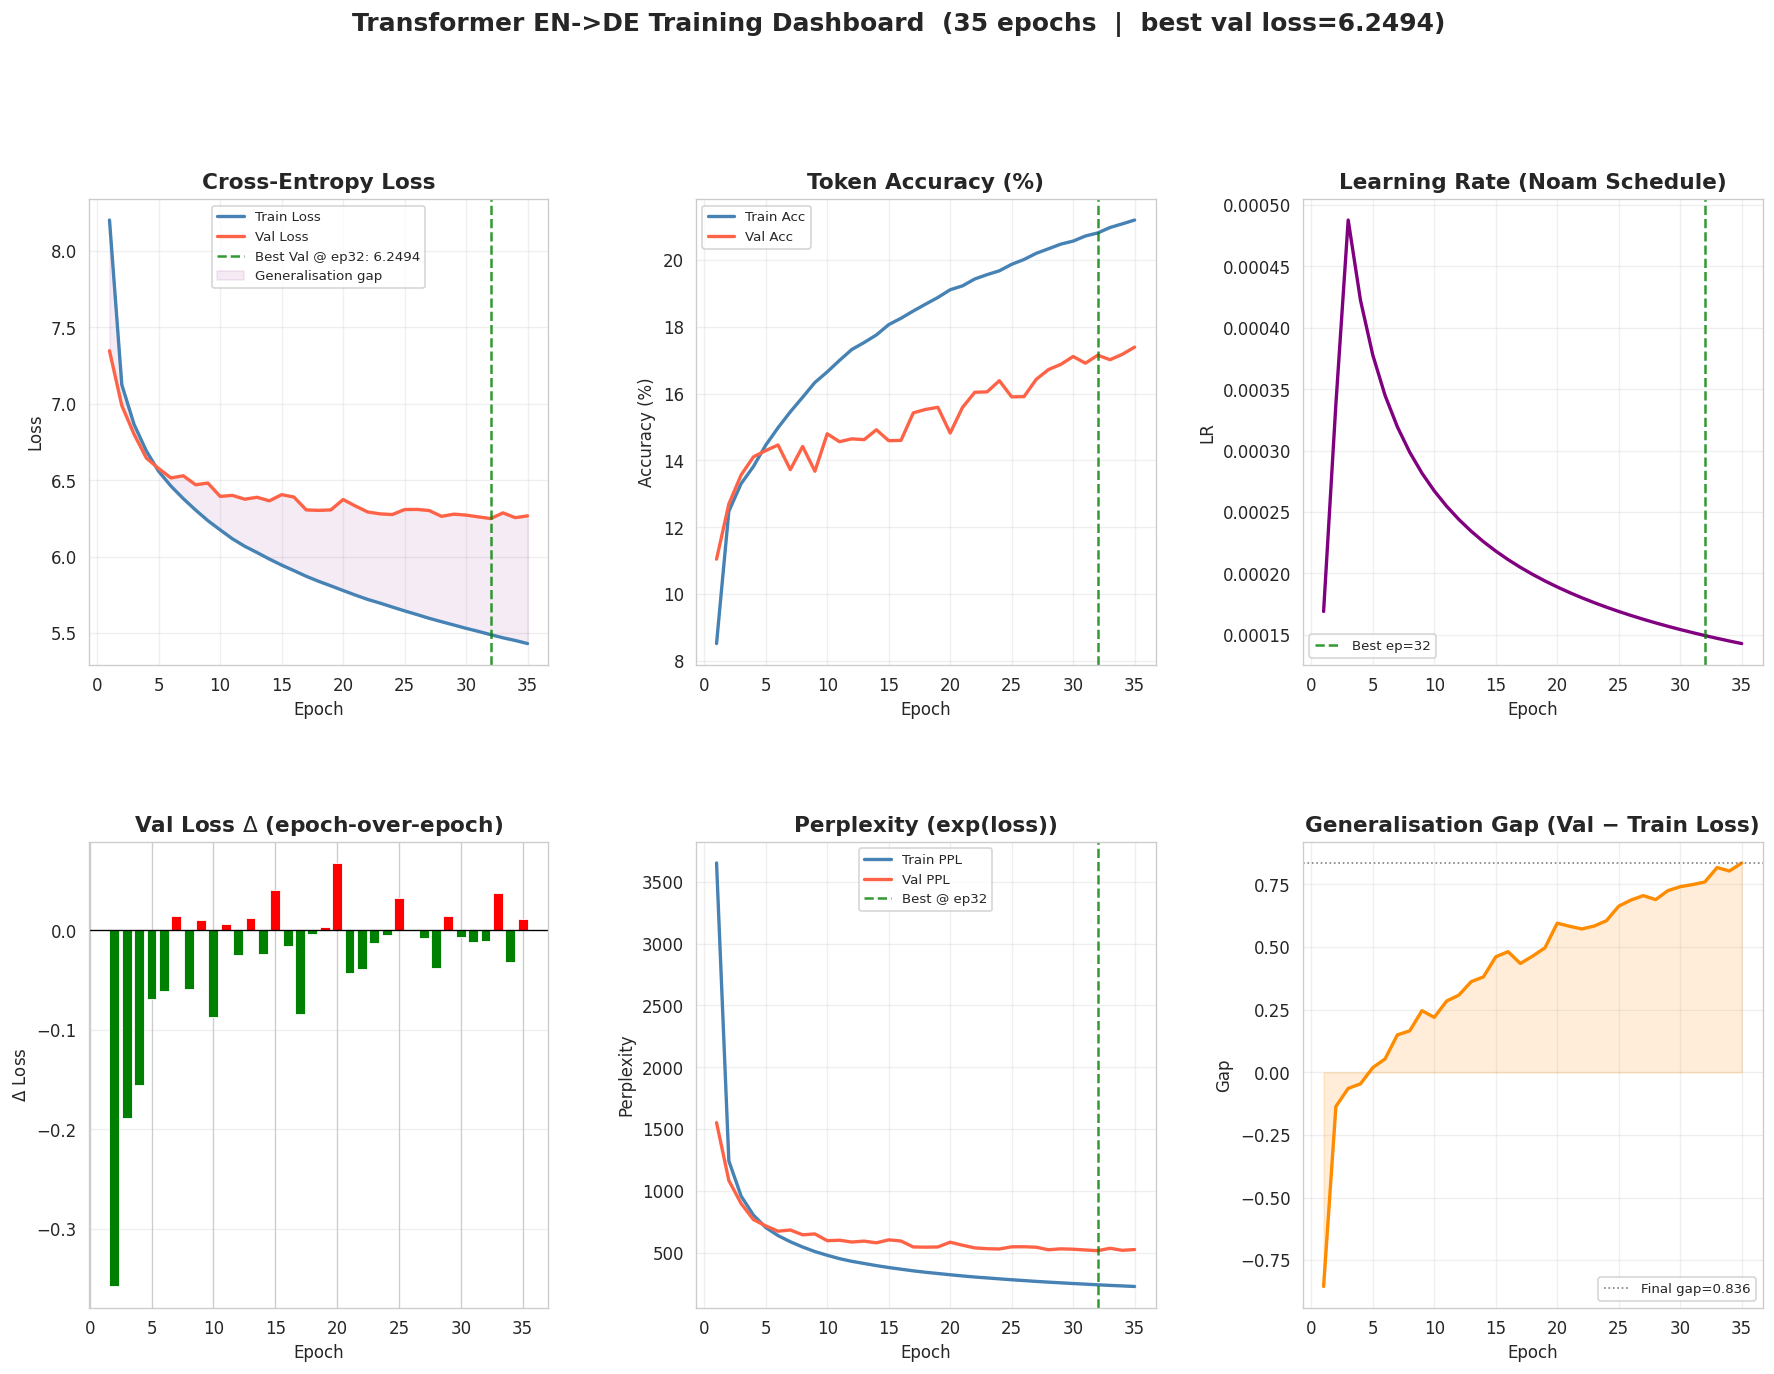

Saved: eval_training_dashboard.png


In [35]:
epochs = history['epoch']
train_loss = history['train_loss']
val_loss   = history['val_loss']
train_acc  = [a * 100 for a in history['train_acc']]
val_acc    = [a * 100 for a in history['val_acc']]
lr_history = history['lr']

best_idx   = val_loss.index(min(val_loss))
best_ep    = epochs[best_idx]

fig = plt.figure(figsize=(18, 12))
gs  = GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.32)

# Loss
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(epochs, train_loss, color='steelblue',  lw=2, label='Train Loss')
ax1.plot(epochs, val_loss,   color='tomato',     lw=2, label='Val Loss')
ax1.axvline(best_ep, color='green', ls='--', lw=1.5, alpha=0.8,
            label=f'Best Val @ ep{best_ep}: {min(val_loss):.4f}')
ax1.fill_between(epochs, train_loss, val_loss, alpha=0.08, color='purple',
                 label='Generalisation gap')
ax1.set_title('Cross-Entropy Loss', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

# Token Accuracy
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(epochs, train_acc, color='steelblue', lw=2, label='Train Acc')
ax2.plot(epochs, val_acc,   color='tomato',    lw=2, label='Val Acc')
ax2.axvline(best_ep, color='green', ls='--', lw=1.5, alpha=0.8)
ax2.set_title('Token Accuracy (%)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

# Learning Rate (Noam)
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(epochs, lr_history, color='purple', lw=2)
ax3.axvline(best_ep, color='green', ls='--', lw=1.5, alpha=0.8,
            label=f'Best ep={best_ep}')
ax3.set_title('Learning Rate (Noam Schedule)', fontsize=13, fontweight='bold')
ax3.set_xlabel('Epoch'); ax3.set_ylabel('LR')
ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)

# Loss delta (epoch-over-epoch improvement)
ax4 = fig.add_subplot(gs[1, 0])
val_delta = np.diff(val_loss)
colors    = ['green' if d < 0 else 'red' for d in val_delta]
ax4.bar(epochs[1:], val_delta, color=colors, edgecolor='white', linewidth=0.5)
ax4.axhline(0, color='black', lw=0.8)
ax4.set_title(r'Val Loss $\Delta$ (epoch-over-epoch)', fontsize=13, fontweight='bold')
ax4.set_xlabel('Epoch'); ax4.set_ylabel(r'$\Delta$ Loss')
ax4.grid(True, alpha=0.3, axis='y')

# Perplexity
ax5 = fig.add_subplot(gs[1, 1])
train_ppl = [math.exp(min(l, 20)) for l in train_loss]
val_ppl   = [math.exp(min(l, 20)) for l in val_loss]
ax5.plot(epochs, train_ppl, color='steelblue', lw=2, label='Train PPL')
ax5.plot(epochs, val_ppl,   color='tomato',    lw=2, label='Val PPL')
ax5.axvline(best_ep, color='green', ls='--', lw=1.5, alpha=0.8,
            label=f'Best @ ep{best_ep}')
ax5.set_title('Perplexity (exp(loss))', fontsize=13, fontweight='bold')
ax5.set_xlabel('Epoch'); ax5.set_ylabel('Perplexity')
ax5.legend(fontsize=8); ax5.grid(True, alpha=0.3)

# Generalisation gap
ax6 = fig.add_subplot(gs[1, 2])
gap = [v - t for v, t in zip(val_loss, train_loss)]
ax6.plot(epochs, gap, color='darkorange', lw=2)
ax6.axhline(gap[-1], color='gray', ls=':', lw=1, label=f'Final gap={gap[-1]:.3f}')
ax6.fill_between(epochs, gap, alpha=0.15, color='darkorange')
ax6.set_title('Generalisation Gap (Val − Train Loss)', fontsize=13, fontweight='bold')
ax6.set_xlabel('Epoch'); ax6.set_ylabel('Gap')
ax6.legend(fontsize=8); ax6.grid(True, alpha=0.3)

fig.suptitle(f'Transformer EN->DE Training Dashboard  '
             f'({len(epochs)} epochs  |  best val loss={min(val_loss):.4f})',
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig('eval_training_dashboard.png', dpi=120, bbox_inches='tight')
plt.show(); plt.close()
print("Saved: eval_training_dashboard.png")

# Per-Checkpoint Performance (Multi-Epoch Comparison)

Available checkpoints for comparison:
  epoch=20      ./checkpoints/epoch_0020.pt  (758 MB)
  epoch=25      ./checkpoints/epoch_0025.pt  (758 MB)
  epoch=30      ./checkpoints/epoch_0030.pt  (758 MB)
  epoch=35      ./checkpoints/epoch_0035.pt  (758 MB)
  epoch=best    ./checkpoints/best_model.pt  (758 MB)

Evaluating checkpoints on validation set (first 30 batches)...
[Transformer] Built model with 63,082,496 trainable parameters
  d_model=512, n_heads=8, n_layers=6, d_ff=2048
  Loaded: epoch_0020.pt
  Epoch: 20  |  Saved val_loss: 6.3739
  ep=20      loss=6.3860  acc=14.72%  ppl=593.49
[Transformer] Built model with 63,082,496 trainable parameters
  d_model=512, n_heads=8, n_layers=6, d_ff=2048
  Loaded: epoch_0025.pt
  Epoch: 25  |  Saved val_loss: 6.3084
  ep=25      loss=6.3236  acc=15.84%  ppl=557.55
[Transformer] Built model with 63,082,496 trainable parameters
  d_model=512, n_heads=8, n_layers=6, d_ff=2048
  Loaded: epoch_0030.pt
  Epoch: 30  |  Saved val_loss: 6.2721
  ep=30 

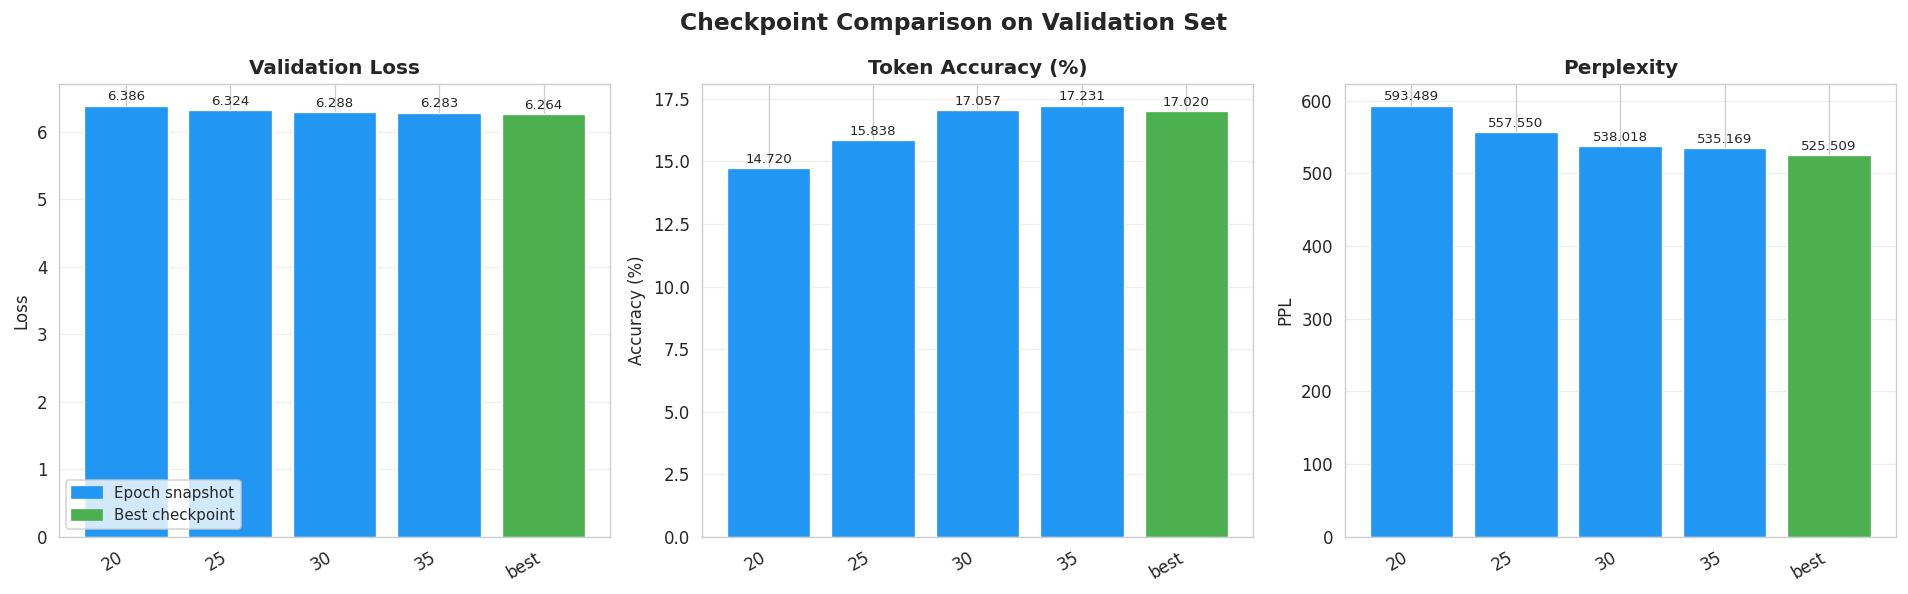

Saved: eval_checkpoint_comparison.png


In [36]:
available_checkpoints = {}
for fname in sorted(os.listdir(CHECKPOINT_DIR)):
    if fname.startswith('epoch_') and fname.endswith('.pt'):
        ep_num = int(fname.replace('epoch_', '').replace('.pt', ''))
        available_checkpoints[ep_num] = os.path.join(CHECKPOINT_DIR, fname)

# Add best
available_checkpoints['best'] = BEST_MODEL_PATH

print("Available checkpoints for comparison:")
for k, v in available_checkpoints.items():
    size_mb = os.path.getsize(v) / 1e6
    print(f"  epoch={k:<6}  {v}  ({size_mb:.0f} MB)")

def quick_val_metrics(ckpt_path, loader, device, n_batches=30):
    """Compute loss + token accuracy on first n_batches of loader."""
    m, ep, _ = load_model(ckpt_path, device)
    criterion = LabelSmoothingLoss(cfg.vocab_size, cfg.PAD_IDX, cfg.label_smoothing)
    m.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for i, (src, tgt_in, tgt_out) in enumerate(loader):
            if i >= n_batches: break
            src, tgt_in, tgt_out = src.to(device), tgt_in.to(device), tgt_out.to(device)
            logits = m(src, tgt_in)
            total_loss += criterion(logits, tgt_out).item()
            pred = logits.argmax(-1)
            mask = tgt_out != cfg.PAD_IDX
            correct += ((pred == tgt_out) & mask).sum().item()
            total   += mask.sum().item()
    return ep, total_loss / n_batches, correct / max(total, 1)

# Evaluate each checkpoint
ckpt_results = {}
print("\nEvaluating checkpoints on validation set (first 30 batches)...")
for ep_key, path in available_checkpoints.items():
    ep, loss, acc = quick_val_metrics(path, val_loader, device)
    ckpt_results[ep_key] = {'epoch': ep, 'val_loss': loss, 'val_acc': acc,
                             'val_ppl': math.exp(min(loss, 20))}
    print(f"  ep={ep_key:<6}  loss={loss:.4f}  acc={acc:.2%}  ppl={math.exp(min(loss,20)):.2f}")

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
labels = [str(k) for k in ckpt_results.keys()]
losses = [v['val_loss'] for v in ckpt_results.values()]
accs   = [v['val_acc'] * 100 for v in ckpt_results.values()]
ppls   = [v['val_ppl'] for v in ckpt_results.values()]

x = np.arange(len(labels))
bar_colors = ['#2196F3' if k != 'best' else '#4CAF50' for k in ckpt_results.keys()]

for ax, vals, title, ylabel in zip(
    axes,
    [losses, accs, ppls],
    ['Validation Loss', 'Token Accuracy (%)', 'Perplexity'],
    ['Loss', 'Accuracy (%)', 'PPL']
):
    bars = ax.bar(x, vals, color=bar_colors, edgecolor='white', linewidth=0.8)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha='right')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005 * max(vals),
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

patch_b = mpatches.Patch(color='#2196F3', label='Epoch snapshot')
patch_g = mpatches.Patch(color='#4CAF50', label='Best checkpoint')
axes[0].legend(handles=[patch_b, patch_g], fontsize=9)

plt.suptitle('Checkpoint Comparison on Validation Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eval_checkpoint_comparison.png', dpi=120, bbox_inches='tight')
plt.show(); plt.close()
print("Saved: eval_checkpoint_comparison.png")